In [10]:
import yfinance as yf
df = yf.download("AAPL", start="2024-01-01", end="2024-12-31")
df = df.dropna()
df.head()

import yfinance as yf
import talib as ta
import pandas as pd

# STEP 1: Download data
df = yf.download("AAPL", start="2024-01-01", end="2024-12-31")

# STEP 2: Select the correct Close Series from MultiIndex
close = df[("Close", "AAPL")].values.astype(float)

# STEP 3: Apply TA-Lib indicators
df["SMA20"] = ta.SMA(close, timeperiod=20)
df["EMA20"] = ta.EMA(close, timeperiod=20)
df["RSI"] = ta.RSI(close, timeperiod=14)

# STEP 4: Show result
df.head()


C:\Users\Asus vivobook\AppData\Local\Temp\ipykernel_26312\1907838901.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2024-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
C:\Users\Asus vivobook\AppData\Local\Temp\ipykernel_26312\1907838901.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2024-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,SMA20,EMA20,RSI
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2024-01-02,183.903229,186.677036,182.169601,185.399096,82488700,NaN,NaN,NaN
2024-01-03,182.526215,184.140970,181.713879,182.496496,58414500,NaN,NaN,NaN
2024-01-04,180.208130,181.377083,179.187767,180.445875,71983600,NaN,NaN,NaN
2024-01-05,179.484940,181.050159,178.484394,180.287374,62379700,NaN,NaN,NaN
2024-01-08,183.823975,183.863609,179.801961,180.386437,59144500,NaN,NaN,NaN


In [11]:
import numpy as np

# Daily Returns
df["returns"] = df["Close"].pct_change()

# Annualized Volatility
vol = df["returns"].std() * np.sqrt(252)

# Sharpe Ratio (risk-free rate = 0)
sharpe = df["returns"].mean() / df["returns"].std() * np.sqrt(252)

vol, sharpe


(np.float64(0.22448827905966343), np.float64(1.5098660532343904))

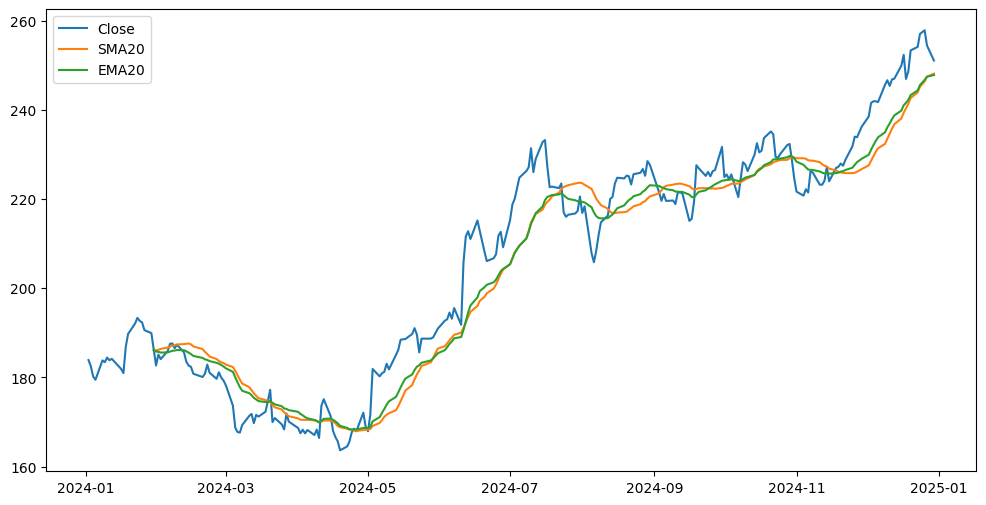

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Close"], label="Close")
plt.plot(df["SMA20"], label="SMA20")
plt.plot(df["EMA20"], label="EMA20")
plt.legend()
plt.show()


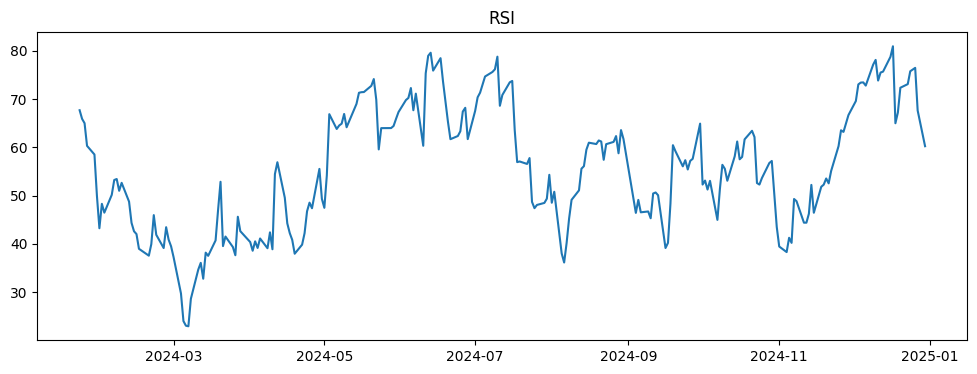

In [13]:
plt.figure(figsize=(12,4))
plt.plot(df["RSI"])
plt.title("RSI")
plt.show()
